# Introduction

Google Trends gives us an estimate of search volume. Let's explore if search popularity relates to other kinds of data. Perhaps there are patterns in Google's search volume and the price of Bitcoin or a hot stock like Tesla. Perhaps search volume for the term "Unemployment Benefits" can tell us something about the actual unemployment rate? 

Data Sources: <br>
<ul>
<li> <a href="https://fred.stlouisfed.org/series/UNRATE/">Unemployment Rate from FRED</a></li>
<li> <a href="https://trends.google.com/trends/explore">Google Trends</a> </li>  
<li> <a href="https://finance.yahoo.com/quote/TSLA/history?p=TSLA">Yahoo Finance for Tesla Stock Price</a> </li>    
<li> <a href="https://finance.yahoo.com/quote/BTC-USD/history?p=BTC-USD">Yahoo Finance for Bitcoin Stock Price</a> </li>
</ul>

# Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format

# Read the Data

Download and add the .csv files to the same folder as your notebook.

In [2]:
df_tesla = pd.read_csv('../data/tesla_search_trend_vs_price.csv')

df_btc_search = pd.read_csv('../data/bitcoin_search_trend.csv')
df_btc_price = pd.read_csv('../data/daily_bitcoin_price.csv')

df_unemployment = pd.read_csv('../data/ue_benefits_search_vs_ue_rate_2004_19.csv')

# Data Exploration

### Tesla

**Challenge**: <br>
<ul>
<li>What are the shapes of the dataframes? </li>
<li>How many rows and columns? </li>
<li>What are the column names? </li>
<li>Complete the f-string to show the largest/smallest number in the search data column</li> 
<li>Try the <code>.describe()</code> function to see some useful descriptive statistics</li>
<li>What is the periodicity of the time series data (daily, weekly, monthly)? </li>
<li>What does a value of 100 in the Google Trend search popularity actually mean?</li>
</ul>

In [3]:
print("Tesla describe:")
print(df_tesla.describe())
print("---"*20)
print("Tesla info:")
print(df_tesla.info())

Tesla describe:
       TSLA_WEB_SEARCH  TSLA_USD_CLOSE
count           124.00          124.00
mean              8.73           50.96
std               5.87           65.91
min               2.00            3.90
25%               3.75            7.35
50%               8.00           44.65
75%              12.00           58.99
max              31.00          498.32
------------------------------------------------------------
Tesla info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MONTH            124 non-null    object 
 1   TSLA_WEB_SEARCH  124 non-null    int64  
 2   TSLA_USD_CLOSE   124 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.0+ KB
None


In [4]:
print("Bitcoin search describe:\n")
print(df_btc_search.describe())
print("---"*20)
print("Bitcoin search info:\n")
print(df_btc_search.info())

Bitcoin search describe:

       BTC_NEWS_SEARCH
count            73.00
mean             15.01
std              15.15
min               3.00
25%               5.00
50%              14.00
75%              18.00
max             100.00
------------------------------------------------------------
Bitcoin search info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   MONTH            73 non-null     object
 1   BTC_NEWS_SEARCH  73 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ KB
None


In [5]:
print("Bitcoin price head:\n")
print(df_btc_price.head())  
print("---"*20)
print("Bitcoin price info:\n")
print(df_btc_price.info())
print("---"*20)
print("Bitcoin price describe:\n")
print(df_btc_price.describe())

Bitcoin price head:

         DATE  CLOSE        VOLUME
0  2014-09-17 457.33 21,056,800.00
1  2014-09-18 424.44 34,483,200.00
2  2014-09-19 394.80 37,919,700.00
3  2014-09-20 408.90 36,863,600.00
4  2014-09-21 398.82 26,580,100.00
------------------------------------------------------------
Bitcoin price info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2204 entries, 0 to 2203
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    2204 non-null   object 
 1   CLOSE   2203 non-null   float64
 2   VOLUME  2203 non-null   float64
dtypes: float64(2), object(1)
memory usage: 51.8+ KB
None
------------------------------------------------------------
Bitcoin price describe:

          CLOSE            VOLUME
count  2,203.00          2,203.00
mean   4,429.42  8,043,622,390.14
std    4,148.15 11,765,285,602.39
min      178.10      5,914,570.00
25%      433.63     60,299,150.00
50%    3,637.52  2,018,889,984.00
75%    7,997.3

In [6]:
print("DF Unemployment head:\n")
print(df_unemployment.head())  
print("---"*20)
print("Bitcoin price info:\n")
print(df_unemployment.info())
print("---"*20)
print("Bitcoin price describe:\n")
print(df_unemployment.describe())

DF Unemployment head:

     MONTH  UE_BENEFITS_WEB_SEARCH  UNRATE
0  2004-01                      34    5.70
1  2004-02                      33    5.60
2  2004-03                      25    5.80
3  2004-04                      29    5.60
4  2004-05                      23    5.60
------------------------------------------------------------
Bitcoin price info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MONTH                   181 non-null    object 
 1   UE_BENEFITS_WEB_SEARCH  181 non-null    int64  
 2   UNRATE                  181 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.4+ KB
None
------------------------------------------------------------
Bitcoin price describe:

       UE_BENEFITS_WEB_SEARCH  UNRATE
count                  181.00  181.00
mean                    35.11    6.22
s

#### 

In [7]:
print(f'Largest value for Tesla in Web Search: {df_tesla["TSLA_WEB_SEARCH"].max()}')
print(f'Smallest value for Tesla in Web Search: {df_tesla["TSLA_WEB_SEARCH"].min()}')

Largest value for Tesla in Web Search: 31
Smallest value for Tesla in Web Search: 2


### Unemployment Data

In [8]:
print('Largest value for "Unemployemnt Benefits" '
      f'in Web Search: {df_unemployment["UE_BENEFITS_WEB_SEARCH"].max()}')

Largest value for "Unemployemnt Benefits" in Web Search: 100


### Bitcoin

In [9]:
print(f'largest BTC News Search: ')
print(df_btc_search['BTC_NEWS_SEARCH'].max())

largest BTC News Search: 
100


# Data Cleaning

### Check for Missing Values

**Challenge**: Are there any missing values in any of the dataframes? If so, which row/rows have missing values? How many missing values are there?

In [10]:
print(f'Missing values for Tesla?: ')
print(df_tesla.isnull().sum())
print(f'Missing values for U/E?: ')
print(df_unemployment.isnull().sum())  
print(f'Missing values for BTC Search?: ')
print(df_btc_search.isnull().sum())

Missing values for Tesla?: 
MONTH              0
TSLA_WEB_SEARCH    0
TSLA_USD_CLOSE     0
dtype: int64
Missing values for U/E?: 
MONTH                     0
UE_BENEFITS_WEB_SEARCH    0
UNRATE                    0
dtype: int64
Missing values for BTC Search?: 
MONTH              0
BTC_NEWS_SEARCH    0
dtype: int64


In [11]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.33,"21,056,800.00"
1,2014-09-18,424.44,"34,483,200.00"
2,2014-09-19,394.80,"37,919,700.00"
3,2014-09-20,408.90,"36,863,600.00"
4,2014-09-21,398.82,"26,580,100.00"


In [12]:
print(f'Missing values for BTC price?: ')
print(df_btc_price.isnull().sum())


Missing values for BTC price?: 
DATE      0
CLOSE     1
VOLUME    1
dtype: int64


In [13]:
print('take a closer look at the missing values in BTC price:')
print(df_btc_price[df_btc_price['CLOSE'].isnull()])

take a closer look at the missing values in BTC price:
            DATE  CLOSE  VOLUME
2148  2020-08-04    NaN     NaN


In [14]:
print(f'Number of missing values: {df_btc_price.isnull().sum().sum()}')

Number of missing values: 2


**Challenge**: Remove any missing values that you found. 

In [15]:
df_btc_price.dropna(inplace=True)
print(f'Number of missing values: {df_btc_price.isnull().sum().sum()}')

Number of missing values: 0


### Convert Strings to DateTime Objects

**Challenge**: Check the data type of the entries in the DataFrame MONTH or DATE columns. Convert any strings in to Datetime objects. Do this for all 4 DataFrames. Double check if your type conversion was successful.

In [16]:
# print(df_tesla.head())
# print(df_btc_price.head())
# print(df_btc_search.head())
# print(df_unemployment.head())

In [17]:
df_tesla['MONTH'] = pd.to_datetime(df_tesla['MONTH'])

df_btc_price['DATE'] = pd.to_datetime(df_btc_price['DATE'])

df_btc_search['MONTH'] = pd.to_datetime(df_btc_search['MONTH'])

df_unemployment['MONTH'] = pd.to_datetime(df_unemployment['MONTH'])


In [18]:
# Test datetime conversion for all DataFrames

tests = {
    "df_tesla MONTH": df_tesla["MONTH"],
    "df_btc_price DATE": df_btc_price["DATE"],
    "df_btc_search MONTH": df_btc_search["MONTH"],
    "df_unemployment MONTH": df_unemployment["MONTH"],
}

for name, series in tests.items():
    print(f"\n{name}")
    print("dtype:", series.dtype)
    print("sample value type:", type(series.iloc[0]))



df_tesla MONTH
dtype: datetime64[ns]
sample value type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>

df_btc_price DATE
dtype: datetime64[ns]
sample value type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>

df_btc_search MONTH
dtype: datetime64[ns]
sample value type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>

df_unemployment MONTH
dtype: datetime64[ns]
sample value type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>


### Converting from Daily to Monthly Data

[Pandas .resample() documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.resample.html) <br>

In [19]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.33,"21,056,800.00"
1,2014-09-18,424.44,"34,483,200.00"
2,2014-09-19,394.80,"37,919,700.00"
3,2014-09-20,408.90,"36,863,600.00"
4,2014-09-21,398.82,"26,580,100.00"


In [20]:
# Convert daily Bitcoin price data to monthly data (month-end prices)
# ---------------------------------------------------------------
# Why this is needed:
# - Bitcoin price data is DAILY
# - Bitcoin search data is MONTHLY
# - To compare them, both datasets must have the SAME frequency
# - We choose MONTH-END prices because this is standard in financial analysis

df_btc_monthly = (
    df_btc_price
    # Resample the data to MONTH-END frequency
    # 'ME' = Month End (new, explicit Pandas alias; replaces deprecated 'M')
    # on='DATE' tells Pandas which column represents time
    .resample('ME', on='DATE')
    
    # Take the LAST available row in each month
    # This represents the closing price at the end of the month
    .last()
)

In [21]:
# ---------------------------------------------------------------
# Verify the resampling worked correctly

# Print the shape to confirm the number of rows
# Expected: (73, 3) → matches Bitcoin search dataset
print(df_btc_monthly.shape)

# Display the first few rows to visually inspect the result
df_btc_monthly.head()

(73, 2)


,CLOSE,VOLUME
DATE,,
2014-09-30,386.94,"34,707,300.00"
2014-10-31,338.32,"12,545,400.00"
2014-11-30,378.05,"9,194,440.00"
2014-12-31,320.19,"13,942,900.00"
2015-01-31,217.46,"23,348,200.00"


# Data Visualisation

### Notebook Formatting & Style Helpers

In [22]:
# Create locators for ticks on the time axis
import matplotlib.dates as mdates

# Major ticks: one tick per year
years = mdates.YearLocator()

# Minor ticks: one tick per month
months = mdates.MonthLocator()

# Format how the year labels appear on the x-axis
years_fmt = mdates.DateFormatter('%Y')


In [23]:
# Register date converters to avoid warning messages

from pandas.plotting import register_matplotlib_converters

# Registers Pandas datetime converters with Matplotlib
# Prevents warnings and ensures correct date handling
register_matplotlib_converters()


### Tesla Stock Price v.s. Search Volume

**Challenge:** Plot the Tesla stock price against the Tesla search volume using a line chart and two different axes. Label one axis 'TSLA Stock Price' and the other 'Search Trend'. 

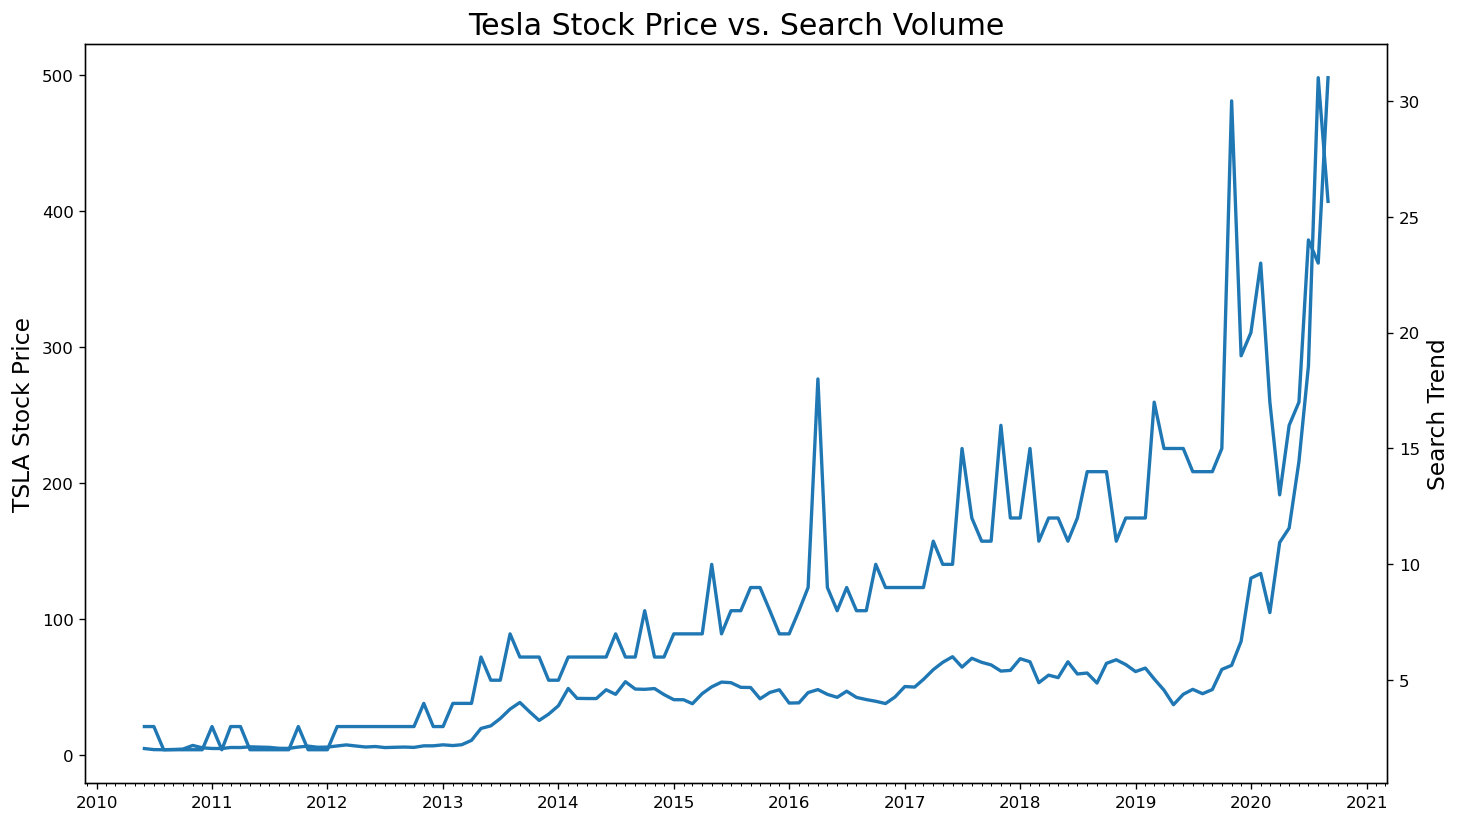

In [24]:
import matplotlib.pyplot as plt

# Create the figure with a readable size and resolution
plt.figure(figsize=(14, 8), dpi=120)

# Get the primary axis (left y-axis)
ax1 = plt.gca()

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# ---- LEFT AXIS: Tesla stock price ----
ax1.plot(
    df_tesla['MONTH'],           # Time axis
    df_tesla['TSLA_USD_CLOSE'],  # Tesla closing price
    linewidth=2
)
ax1.set_ylabel('TSLA Stock Price', fontsize=14)

# ---- RIGHT AXIS: Tesla search trend ----
ax2.plot(
    df_tesla['MONTH'],           # Same time axis
    df_tesla['TSLA_WEB_SEARCH'], # Google search popularity
    linewidth=2
)
ax2.set_ylabel('Search Trend', fontsize=14)

# ---- Apply time-axis locators created earlier ----
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

# Rotate date labels for readability
plt.xticks(rotation=45)

# Chart title
plt.title('Tesla Stock Price vs. Search Volume', fontsize=18)

# Render the chart
plt.show()


**Challenge**: Add colours to style the chart. This will help differentiate the two lines and the axis labels. Try using one of the blue [colour names](https://matplotlib.org/3.1.1/gallery/color/named_colors.html) for the search volume and a HEX code for a red colour for the stock price. 
<br>
<br>
Hint: you can colour both the [axis labels](https://matplotlib.org/3.3.2/api/text_api.html#matplotlib.text.Text) and the [lines](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.lines.Line2D.html#matplotlib.lines.Line2D) on the chart using keyword arguments (kwargs).  

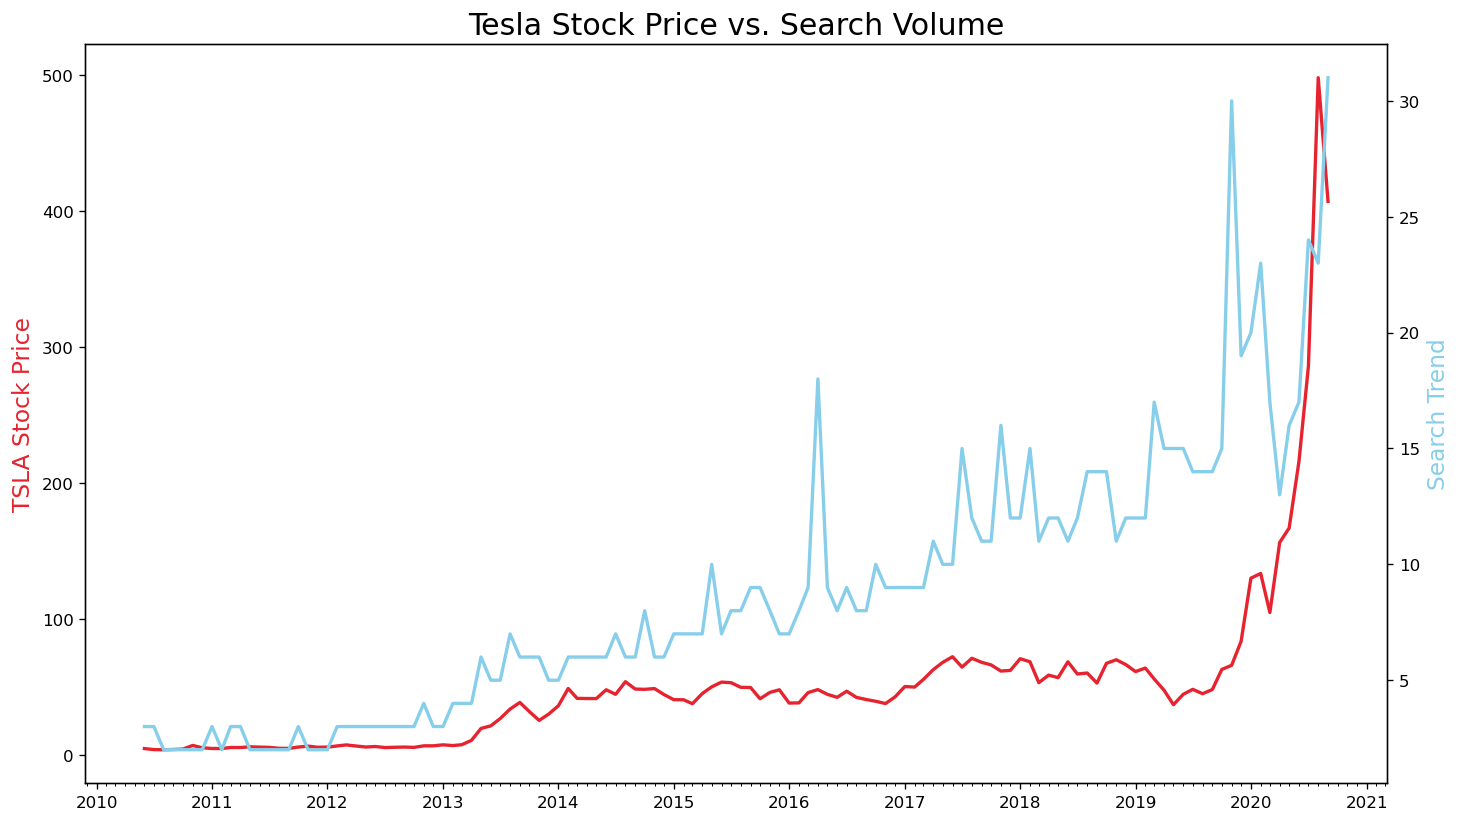

In [25]:
import matplotlib.pyplot as plt

# Create the figure with a readable size and resolution
plt.figure(figsize=(14, 8), dpi=120)

# Get the primary axis (left y-axis)
ax1 = plt.gca()

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# ---- LEFT AXIS: Tesla stock price (red, HEX code) ----
ax1.plot(
    df_tesla['MONTH'],            # Time axis
    df_tesla['TSLA_USD_CLOSE'],   # Tesla closing price
    color='#E6232E',              # Red HEX colour
    linewidth=2
)

ax1.set_ylabel(
    'TSLA Stock Price',
    color='#E6232E',
    fontsize=14
)

# ---- RIGHT AXIS: Tesla search volume (blue colour name) ----
ax2.plot(
    df_tesla['MONTH'],            # Same time axis
    df_tesla['TSLA_WEB_SEARCH'],  # Google search popularity
    color='skyblue',              # Named blue colour
    linewidth=2
)

ax2.set_ylabel(
    'Search Trend',
    color='skyblue',
    fontsize=14
)

# ---- Time-axis formatting using locators ----
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Chart title
plt.title('Tesla Stock Price vs. Search Volume', fontsize=18)

# Render the chart
plt.show()


**Challenge**: Make the chart larger and easier to read. 
1. Increase the figure size (e.g., to 14 by 8). 
2. Increase the font sizes for the labels and the ticks on the x-axis to 14. 
3. Rotate the text on the x-axis by 45 degrees. 
4. Make the lines on the chart thicker. 
5. Add a title that reads 'Tesla Web Search vs Price'
6. Keep the chart looking sharp by changing the dots-per-inch or [DPI value](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.figure.html). 
7. Set minimum and maximum values for the y and x axis. Hint: check out methods like [set_xlim()](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.set_xlim.html). 
8. Finally use [plt.show()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.show.html) to display the chart below the cell instead of relying on the automatic notebook output.

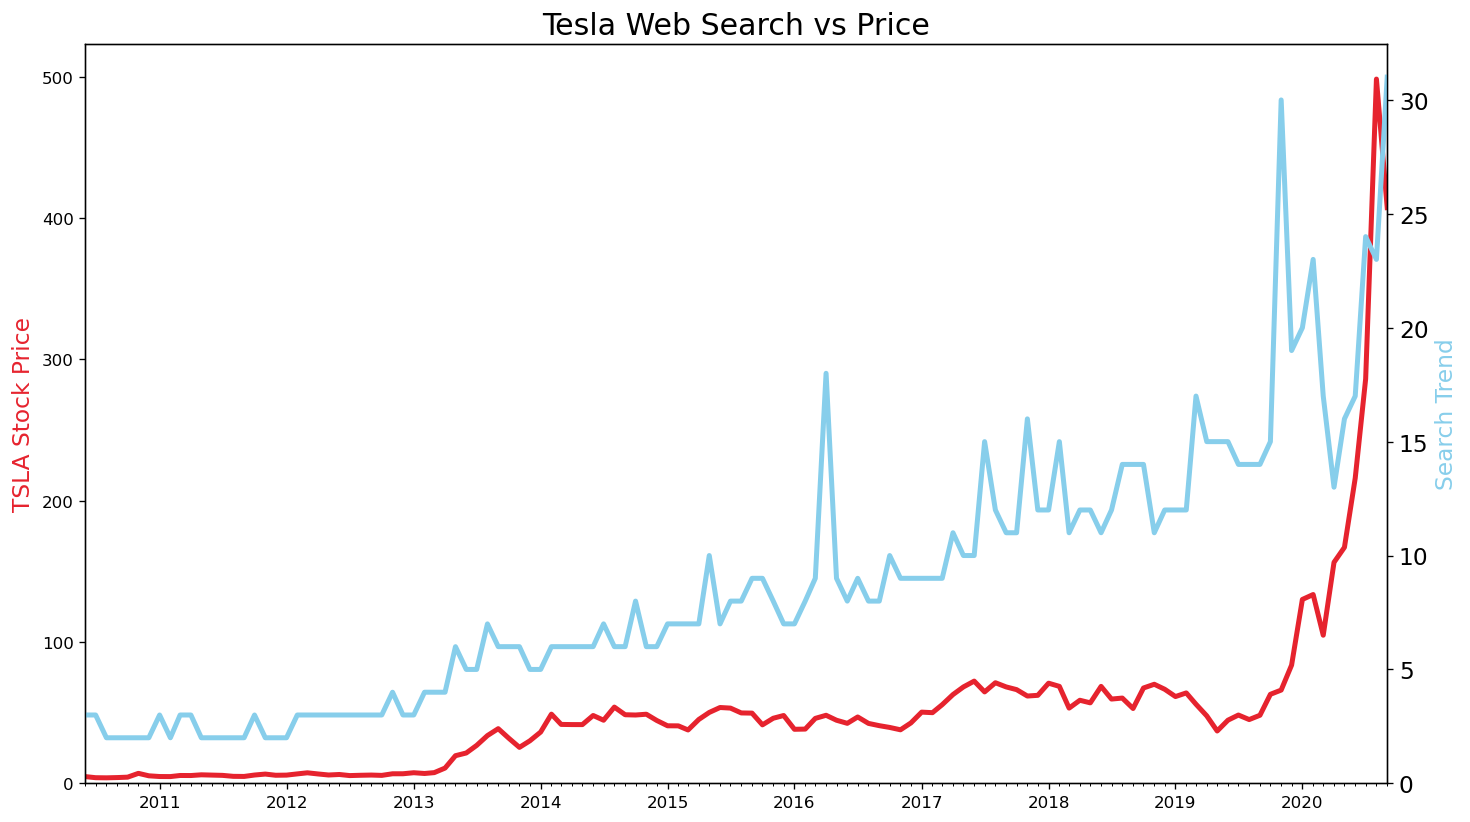

In [26]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Create a larger, sharper figure
# figsize controls physical size, dpi controls sharpness
plt.figure(figsize=(14, 8), dpi=120)

# ---------------------------------------------------------
# 2) Get axes
ax1 = plt.gca()          # Left y-axis
ax2 = ax1.twinx()        # Right y-axis (shared x-axis)

# ---------------------------------------------------------
# 3) Plot Tesla stock price (left axis, red, thicker line)
ax1.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_USD_CLOSE'],
    color='#E6232E',      # Red HEX
    linewidth=3
)

ax1.set_ylabel(
    'TSLA Stock Price',
    color='#E6232E',
    fontsize=14
)

# ---------------------------------------------------------
# 4) Plot Tesla search trend (right axis, blue, thicker line)
ax2.plot(
    df_tesla['MONTH'],
    df_tesla['TSLA_WEB_SEARCH'],
    color='skyblue',
    linewidth=3
)

ax2.set_ylabel(
    'Search Trend',
    color='skyblue',
    fontsize=14
)

# ---------------------------------------------------------
# 5) Improve x-axis date formatting
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

# Rotate x-axis labels and increase tick font size
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# ---------------------------------------------------------
# 6) Set axis limits for cleaner framing
ax1.set_xlim(df_tesla['MONTH'].min(), df_tesla['MONTH'].max())
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# ---------------------------------------------------------
# 7) Add clear, descriptive title
plt.title(
    'Tesla Web Search vs Price',
    fontsize=18
)

# ---------------------------------------------------------
# 8) Explicitly render the chart
plt.show()


How to add tick formatting for dates on the x-axis. 

In [27]:
import matplotlib.dates as mdates

# Major ticks: show one tick per year
years = mdates.YearLocator()

# Minor ticks: show ticks for each month
months = mdates.MonthLocator()

# Formatter: display years as YYYY (e.g. 2015, 2016)
years_fmt = mdates.DateFormatter('%Y')


### Bitcoin (BTC) Price v.s. Search Volume

**Challenge**: Create the same chart for the Bitcoin Prices vs. Search volumes. <br>
1. Modify the chart title to read 'Bitcoin News Search vs Resampled Price' <br>
2. Change the y-axis label to 'BTC Price' <br>
3. Change the y- and x-axis limits to improve the appearance <br>
4. Investigate the [linestyles](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html ) to make the BTC price a dashed line <br>
5. Investigate the [marker types](https://matplotlib.org/3.2.1/api/markers_api.html) to make the search datapoints little circles <br>
6. Were big increases in searches for Bitcoin accompanied by big increases in the price?

In [28]:
df_btc_search.describe()

,MONTH,BTC_NEWS_SEARCH
count,73,73.00
mean,2017-08-31 09:32:03.287671296,15.01
min,2014-09-01 00:00:00,3.00
25%,2016-03-01 00:00:00,5.00
50%,2017-09-01 00:00:00,14.00
75%,2019-03-01 00:00:00,18.00
max,2020-09-01 00:00:00,100.00
std,NaN,15.15


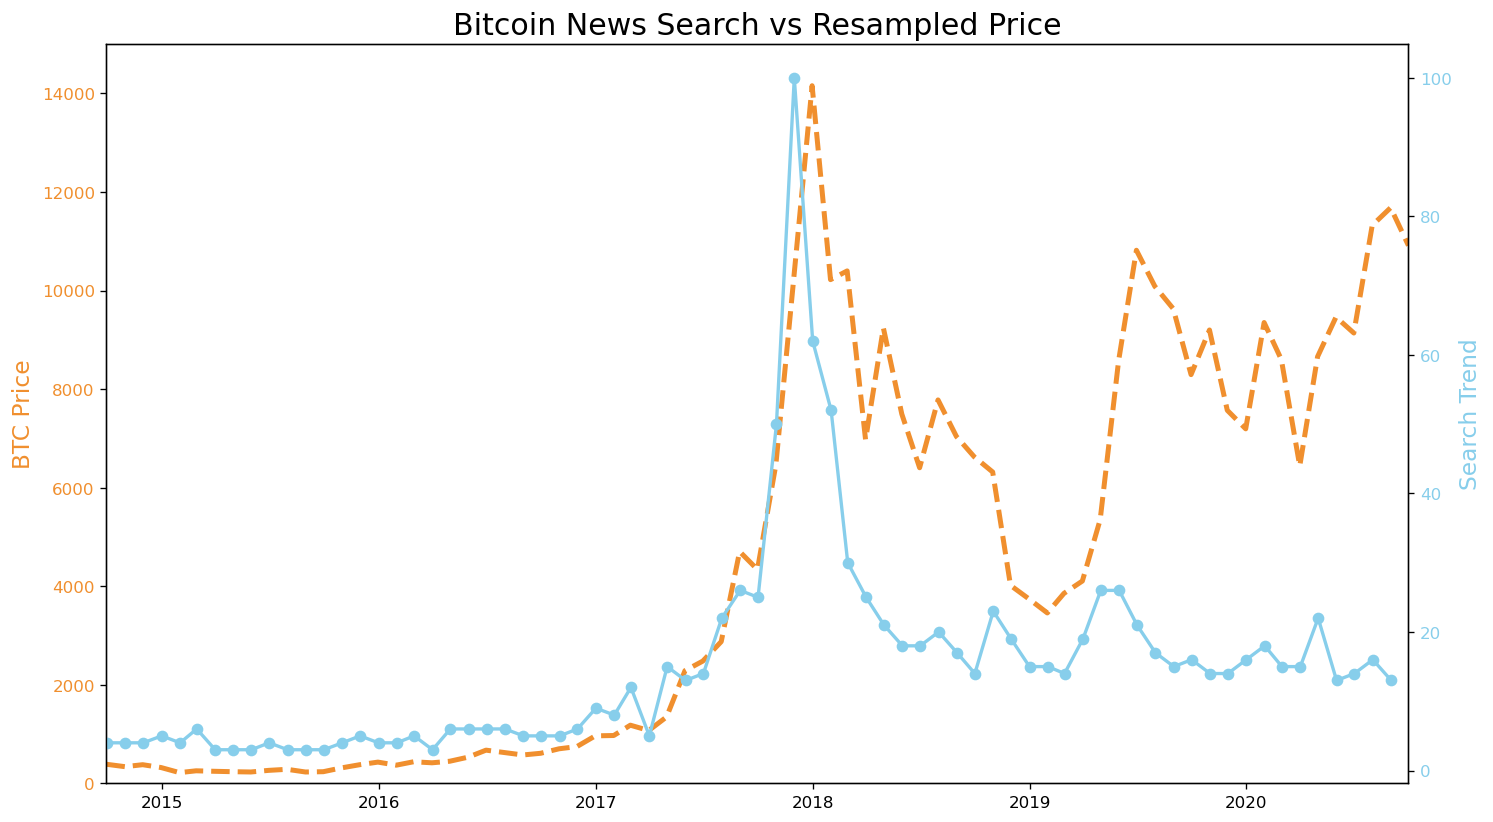

In [29]:
plt.figure(figsize=(14, 8), dpi=120)

# Get primary axis (BTC price)
ax1 = plt.gca()

# Create secondary axis (search trend)
ax2 = ax1.twinx()

# --- Plot BTC PRICE (left axis) ---
ax1.plot(
    df_btc_monthly.index,
    df_btc_monthly.CLOSE,
    color="#F08F2E",          # orange
    linestyle="--",           # dashed line
    linewidth=3,
    label="BTC Price"
)

ax1.set_ylabel("BTC Price", color="#F08F2E", fontsize=14)
ax1.tick_params(axis="y", labelcolor="#F08F2E")

# --- Plot BTC SEARCH TREND (right axis) ---
ax2.plot(
    df_btc_search.MONTH,
    df_btc_search.BTC_NEWS_SEARCH,
    color="skyblue",
    marker="o",               # small circles
    linewidth=2,
    label="Search Trend"
)

ax2.set_ylabel("Search Trend", color="skyblue", fontsize=14)
ax2.tick_params(axis="y", labelcolor="skyblue")

# Title and formatting
plt.title("Bitcoin News Search vs Resampled Price", fontsize=18)
plt.xticks(rotation=45)
plt.xlim(df_btc_monthly.index.min(), df_btc_monthly.index.max())
ax1.set_ylim(0, 15000)

plt.show()


### Unemployement Benefits Search vs. Actual Unemployment in the U.S.

**Challenge** Plot the search for "unemployment benefits" against the unemployment rate. 
1. Change the title to: Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate <br>
2. Change the y-axis label to: FRED U/E Rate <br>
3. Change the axis limits <br>
4. Add a grey [grid](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.grid.html) to the chart to better see the years and the U/E rate values. Use dashes for the line style<br> 
5. Can you discern any seasonality in the searches? Is there a pattern? 

In [30]:
df_unemployment.describe()

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
count,181,181.00,181.00
mean,2011-07-02 01:51:22.872928256,35.11,6.22
min,2004-01-01 00:00:00,14.00,3.70
25%,2007-10-01 00:00:00,21.00,4.70
50%,2011-07-01 00:00:00,26.00,5.40
75%,2015-04-01 00:00:00,45.00,7.80
max,2019-01-01 00:00:00,100.00,10.00
std,NaN,20.48,1.89


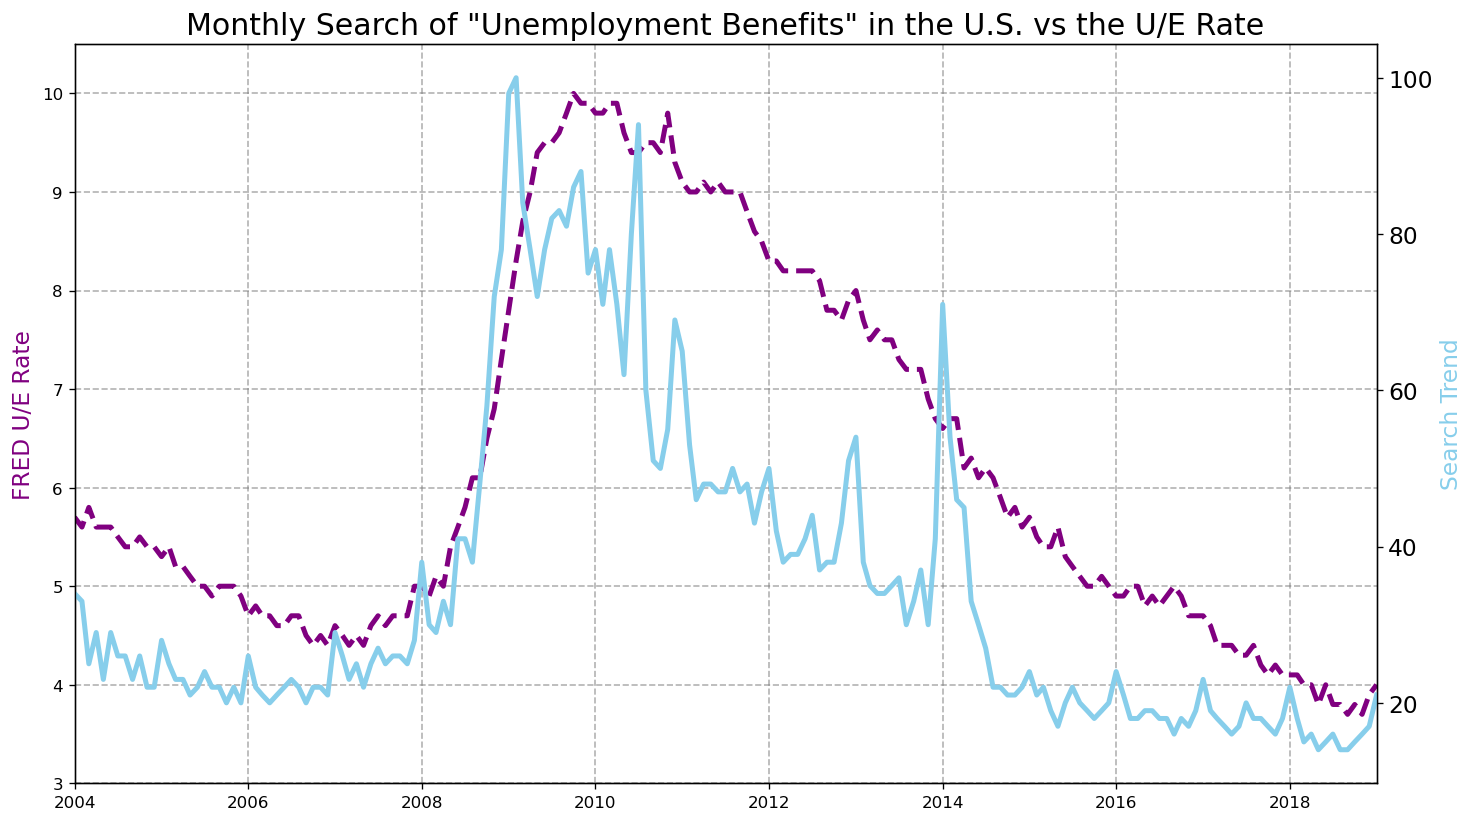

In [31]:
import matplotlib.pyplot as plt

# --- Unemployment Benefits Search vs Actual Unemployment (Dual Axis) ---

plt.figure(figsize=(14, 8), dpi=120)

# 1) Create the two axes (left + right)
ax1 = plt.gca()          # left axis (UNRATE)
ax2 = ax1.twinx()        # right axis (search trend)

# 2) Title + tick formatting
plt.title('Monthly Search of "Unemployment Benefits" in the U.S. vs the U/E Rate', fontsize=18)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)

# 3) Axis labels
ax1.set_ylabel("FRED U/E Rate", color="purple", fontsize=14)
ax2.set_ylabel("Search Trend", color="skyblue", fontsize=14)

# 4) Set axis limits (based on your describe() output)
# UNRATE ranges roughly 3.7 to 10.0, so add a little padding
ax1.set_ylim(bottom=3, top=10.5)

# X-axis: from first to last month in the dataset
ax1.set_xlim(df_unemployment.MONTH.min(), df_unemployment.MONTH.max())

# 5) Add grid (grey dashed lines)
ax1.grid(color="grey", linestyle="--", linewidth=1, alpha=0.6)

# 6) Plot both lines (dash the UNRATE line)
ax1.plot(
    df_unemployment.MONTH,
    df_unemployment.UNRATE,
    color="purple",
    linewidth=3,
    linestyle="--"
)

ax2.plot(
    df_unemployment.MONTH,
    df_unemployment.UE_BENEFITS_WEB_SEARCH,
    color="skyblue",
    linewidth=3
)

plt.show()


**Challenge**: Calculate the 3-month or 6-month rolling average for the web searches. Plot the 6-month rolling average search data against the actual unemployment. What do you see in the chart? Which line moves first?


In [32]:
# Create a 6-month rolling average of the unemployment benefits search data
# This smooths short-term spikes and highlights the underlying trend

df_unemployment["UE_SEARCH_6M_AVG"] = (
    df_unemployment["UE_BENEFITS_WEB_SEARCH"]
    .rolling(window=6)
    .mean()
)

# Quick check to confirm the new column was created
df_unemployment[["MONTH", "UE_BENEFITS_WEB_SEARCH", "UE_SEARCH_6M_AVG"]].head(10)


,MONTH,UE_BENEFITS_WEB_SEARCH,UE_SEARCH_6M_AVG
0,2004-01-01,34,NaN
1,2004-02-01,33,NaN
2,2004-03-01,25,NaN
3,2004-04-01,29,NaN
4,2004-05-01,23,NaN
5,2004-06-01,29,28.83
6,2004-07-01,26,27.50
7,2004-08-01,26,26.33
8,2004-09-01,23,26.00
9,2004-10-01,26,25.50


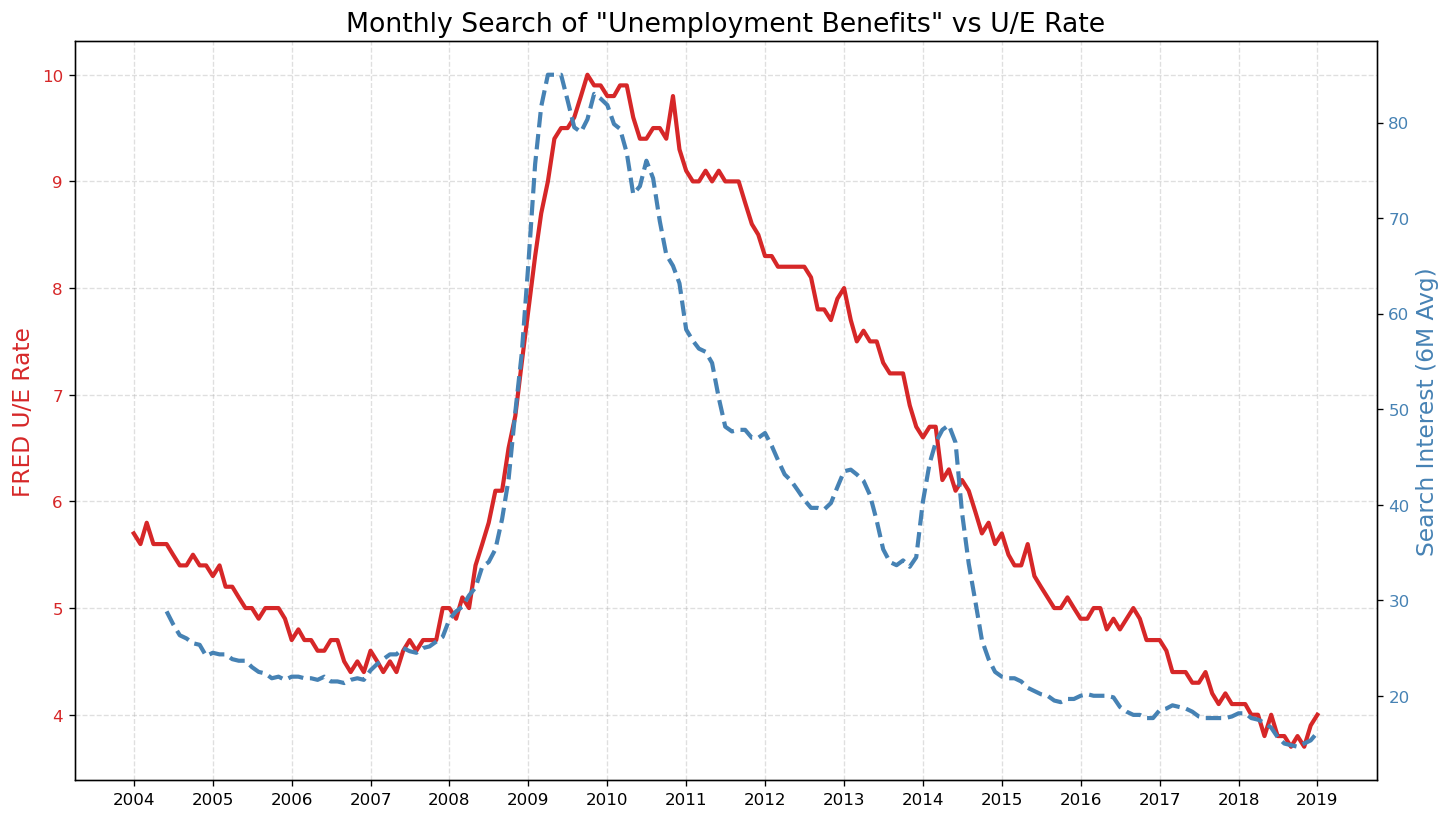

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create a larger, sharper figure
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=120)

# Plot unemployment rate (left y-axis)
ax1.plot(
    df_unemployment["MONTH"],
    df_unemployment["UNRATE"],
    color="#d62728",          # red
    linewidth=2.5,
    label="Unemployment Rate"
)
ax1.set_ylabel("FRED U/E Rate", fontsize=14, color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")

# Create second y-axis for search data
ax2 = ax1.twinx()

# Plot 6-month rolling average of search interest
ax2.plot(
    df_unemployment["MONTH"],
    df_unemployment["UE_SEARCH_6M_AVG"],
    color="steelblue",
    linestyle="--",
    linewidth=2.5,
    label="6M Avg Search Interest"
)
ax2.set_ylabel("Search Interest (6M Avg)", fontsize=14, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

# Title
plt.title(
    'Monthly Search of "Unemployment Benefits" vs U/E Rate',
    fontsize=16
)

# X-axis formatting (year ticks)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45, fontsize=12)

# Grid for readability
ax1.grid(True, linestyle="--", alpha=0.4)

# Display chart
plt.show()


### Including 2020 in Unemployment Charts

**Challenge**: Read the data in the '../data/ue_benefits_search_vs_ue_rate_2004_20.csv' into a DataFrame. Convert the MONTH column to Pandas Datetime objects and then plot the chart. What do you see?

In [34]:
import pandas as pd

# Read the unemployment benefits vs unemployment rate dataset
df_unemployment_2020 = pd.read_csv(
    "../data/ue_benefits_search_vs_ue_rate_2004_20.csv"
)

# Convert MONTH column to pandas datetime
df_unemployment_2020["MONTH"] = pd.to_datetime(df_unemployment_2020["MONTH"])

# Quick inspection
df_unemployment_2020.head()


,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01-01,9,5.70
1,2004-02-01,8,5.60
2,2004-03-01,7,5.80
3,2004-04-01,8,5.60
4,2004-05-01,6,5.60


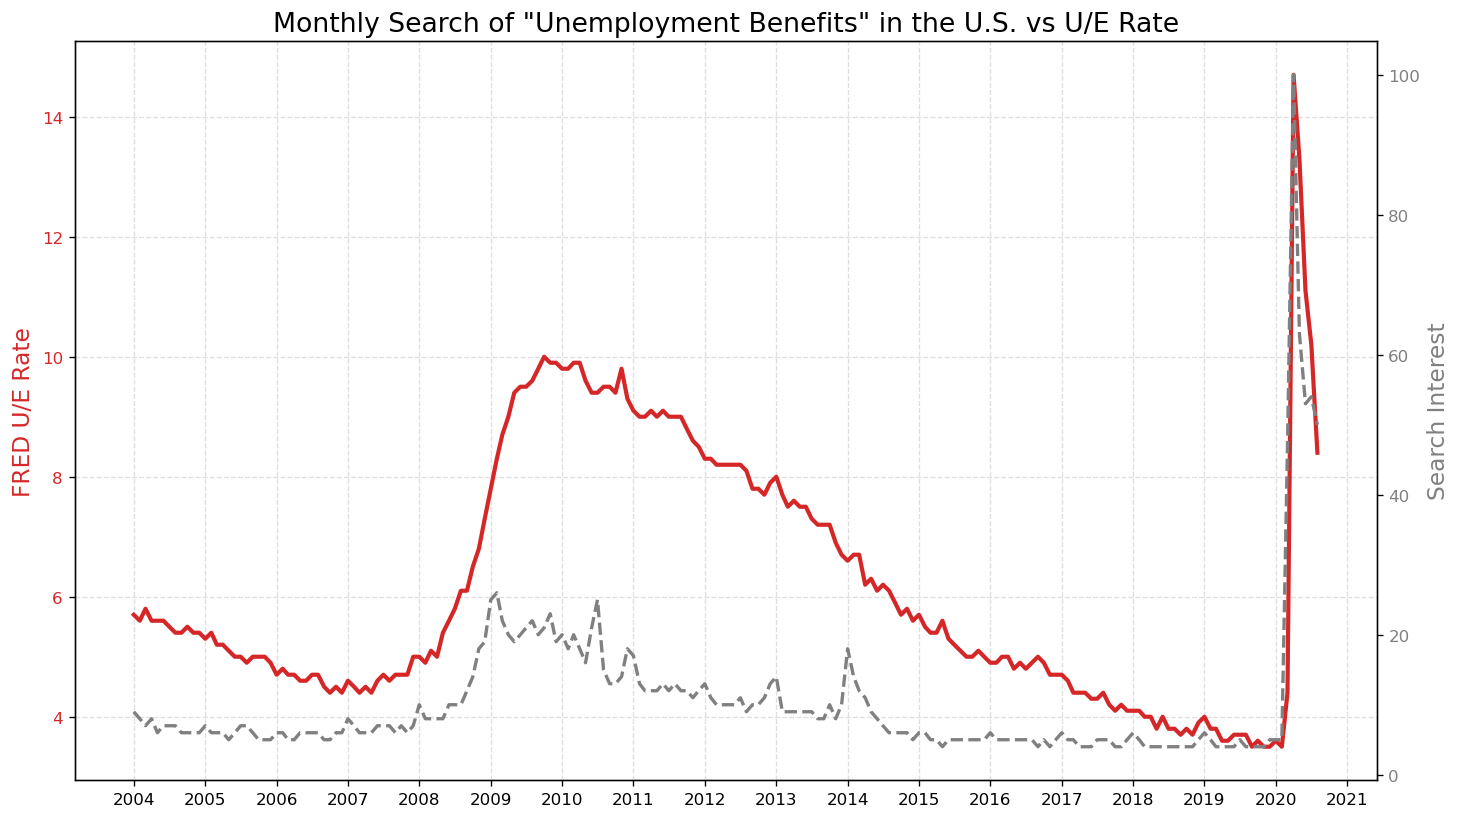

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create figure
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=120)

# Plot unemployment rate (left axis)
ax1.plot(
    df_unemployment_2020["MONTH"],
    df_unemployment_2020["UNRATE"],
    color="#d62728",
    linewidth=2.5,
    label="Unemployment Rate"
)
ax1.set_ylabel("FRED U/E Rate", fontsize=14, color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")

# Second axis for search interest
ax2 = ax1.twinx()

ax2.plot(
    df_unemployment_2020["MONTH"],
    df_unemployment_2020["UE_BENEFITS_WEB_SEARCH"],
    color="gray",
    linestyle="--",
    linewidth=2,
    label="Unemployment Benefits Search"
)
ax2.set_ylabel("Search Interest", fontsize=14, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

# Title
plt.title(
    'Monthly Search of "Unemployment Benefits" in the U.S. vs U/E Rate',
    fontsize=16
)

# X-axis formatting
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

# Grid
ax1.grid(True, linestyle="--", alpha=0.4)

# Display
plt.show()
